# Vintage 报表：Python 实现

基于逐月观测点加工逾期指标并生成 Vintage 报表的 Python 实现。

In [79]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.options.display.max_columns = 50

In [80]:
import matplotlib as mpl
print('pandas:',pd.__version__)
print('numpy:',np.__version__)
print('seaborn:',sns.__version__)
print('matplotlib:',mpl.__version__)

pandas: 2.0.0
numpy: 1.23.5
seaborn: 0.12.2
matplotlib: 3.7.1


### 0.加载数据

In [81]:
# 数据读取
data_act=pd.read_csv("repay_actual_sample.csv")
data_plan = pd.read_csv("repay_plan_sample.csv")
print(data_act.shape)
print(data_plan.shape)

(3148826, 8)
(7724346, 12)


In [70]:
data_act.head(2)

,order_id,order_sub_id,phase,actual_repay_date,actual_repay_amt,actual_repay_prin,actual_repay_int,snapshot_date
0,2010100002350101000,2010100002350101001,1,20220101,3917,3884,33,20221213
1,2010100002350101000,2010100002350101002,2,20220101,3764,3764,0,20221213


In [71]:
data_plan.head(2)

,user_id,order_id,order_sub_id,phase_total,phase,expected_date,create_time,loan_amt,irr_rate,schedule_repay_prin,schedule_repay_int,snapshot_date
0,201100000360790110000,2011000035640110000,2011000035640110010,12,10,20221110,2022-01-10 17:46:31,500000.0,0.24,44545,0,20221110
1,201100000360790110000,2011000035640110000,2011000035640110011,12,11,20221210,2022-01-10 17:46:31,500000.0,0.24,45527,0,20221110


In [82]:
# 数据采用快照的形式进行抓取，提取每月月底最后数据，做数据清洗加工
# 还款计划表采用增量快照记录的方式，故采用最新的数据作为最后的主数据
data_plan12= data_plan[data_plan.snapshot_date==20221214]
data_plan12.shape

(46758, 12)

In [83]:
# len(data_plan12.user_id.unique()) #截至20221214，一共有4760个客户，发生了5031笔合同支用
# len(data_plan12.order_id.unique())

In [84]:
# 实际还款记录表，也采用快照得方式，获取最终切片数据加工,数据范围更大
data_act12 = data_act[data_act.snapshot_date==20221214]

In [85]:
len(data_act12.order_id.unique()) #实际还款记录表一共有5008个合同号，最终数据与最终关联上得数据为准

5008

In [87]:
#---# 挑选vars
data_act_tmp = data_act12[['order_sub_id', 'actual_repay_date',
       'actual_repay_amt', 'actual_repay_prin', 'actual_repay_int']]

data_all= pd.merge(data_plan12, data_act_tmp, on ='order_sub_id', how='left')
data_all.shape

(46758, 16)

In [88]:
# 观测时点为20221231
data_all_1 = data_all[data_all.expected_date<=20221214]
data_all_1.shape

(22112, 16)

In [29]:
# data_all_1.loc[data_all_1['order_id']==2100600067581006000].sort_values('phase')

### 1.加工月末观测点

In [89]:
############################处理时间#########################################
# 定义当前观测时点
now_date = '2022-12-31'
#时间处理， dpd时间加工计算
data_all_1['actual_repay_date']=data_all_1['actual_repay_date'].astype(str).map(lambda x:x[:8])
data_all_1['expected_date']=data_all_1['expected_date'].astype(str)
#时间类型转换
data_all_1['actual_repay_date'] = pd.to_datetime(data_all_1['actual_repay_date'])
data_all_1['expected_date']=pd.to_datetime(data_all_1['expected_date'])
# 加工放款月
data_all_1['create_time'] = pd.to_datetime(data_all_1['create_time']).astype(str).map(lambda x:x[:10])
data_all_1['create_time'] = pd.to_datetime(data_all_1['create_time'])
data_all_1['loan_month'] = data_all_1['create_time'].astype(str).map(lambda x:x[:7])
# 加工mob月底观测日期
def get_month(x) : return dt.datetime(x.year,x.month,int(x.days_in_month))
data_all_1['obser_month_end'] = data_all_1.loc[data_all_1['expected_date'].isna()==False,'expected_date'].apply(get_month)
# 排序
data_all_1 = data_all_1.sort_values(['order_id','phase'],ascending=[True,True])

### 2.加工剩余未还本金

In [90]:
############################本金#########################################
# 计算已还本金累计和
data_all_1['actual_repay_prin_cumsum'] = data_all_1.groupby(['order_id'])['actual_repay_prin'].transform('cumsum')
# 剩余未还本金
data_all_1['balance'] = data_all_1['loan_amt']-data_all_1['actual_repay_prin_cumsum']
# 剩余未还本金下移辅助列(用于后续更新剩余本金)
data_all_1['balance_pre'] = data_all_1.groupby('order_id')['balance'].transform(lambda x:x.shift(1))

In [91]:
data_all_1.head(5)

,user_id,order_id,order_sub_id,phase_total,phase,expected_date,create_time,loan_amt,irr_rate,schedule_repay_prin,schedule_repay_int,snapshot_date,actual_repay_date,actual_repay_amt,actual_repay_prin,actual_repay_int,loan_month,obser_month_end,actual_repay_prin_cumsum,balance,balance_pre
3110,112310000267131231000,2010100000010101000,2010100000010101001,12,1,2022-02-01,2022-01-01,300000.0,0.24,22020,6444,20221214,2022-02-04,28464.0,22020.0,6444.0,2022-01,2022-02-28,22020.0,277980.0,NaN
3109,112310000267131231000,2010100000010101000,2010100000010101002,12,2,2022-03-01,2022-01-01,300000.0,0.24,23231,5189,20221214,2022-03-01,28420.0,23231.0,5189.0,2022-01,2022-03-31,45251.0,254749.0,277980.0
3108,112310000267131231000,2010100000010101000,2010100000010101003,12,3,2022-04-01,2022-01-01,300000.0,0.24,23155,2717,20221214,2022-03-17,25872.0,23155.0,2717.0,2022-01,2022-04-30,68406.0,231594.0,254749.0
3107,112310000267131231000,2010100000010101000,2010100000010101004,12,4,2022-05-01,2022-01-01,300000.0,0.24,23788,6948,20221214,2022-05-01,30736.0,23788.0,6948.0,2022-01,2022-05-31,92194.0,207806.0,231594.0
3106,112310000267131231000,2010100000010101000,2010100000010101005,12,5,2022-06-01,2022-01-01,300000.0,0.24,24125,3325,20221214,2022-05-25,27450.0,24125.0,3325.0,2022-01,2022-06-30,116319.0,183681.0,207806.0


### 3.加工逾期标识/类型/更新剩余未还本金

In [94]:
############################逾期标识#########################################
# 加工出逾期标志、和辅助列（用于判断本期和上一期）
data_all_1['odu_flag'] = 0
data_all_1.loc[(data_all_1['actual_repay_date']>data_all_1['obser_month_end'])|(data_all_1['actual_repay_date'].isnull()),'odu_flag'] = 1
data_all_1['odu_flag_pre'] = data_all_1.groupby('order_id')['odu_flag'].transform(lambda x:x.shift(1))
data_all_1['actual_repay_date_pre'] = data_all_1.groupby('order_id')['actual_repay_date'].transform(lambda x:x.shift(1))

# 定义逾期的类型 & 更新剩余未还本金
data_all_1['odu_type'] = 0

# 1.1 第一期逾期
data_all_1.loc[(data_all_1['odu_flag_pre'].isnull()==True)&(data_all_1['odu_flag']==1),'odu_type'] = 1
data_all_1.loc[(data_all_1['odu_flag_pre'].isnull()==True)&(data_all_1['odu_flag']==1),'balance'] = data_all_1['loan_amt']

# 1.2 非第一期逾期，上一期未逾期，本期逾期
data_all_1.loc[(data_all_1['odu_flag_pre']==0)&(data_all_1['odu_flag']==1),'odu_type'] = 2
data_all_1.loc[(data_all_1['odu_flag_pre']==0)&(data_all_1['odu_flag']==1),'balance'] = data_all_1['balance_pre']

# 1.3 非第一期逾期，上一期逾期（本期月末观察点之前还了），本期逾期
data_all_1.loc[(data_all_1['odu_flag_pre']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date_pre']<=data_all_1['obser_month_end']),'odu_type'] = 3
data_all_1.loc[(data_all_1['odu_flag_pre']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date_pre']<=data_all_1['obser_month_end']),'balance'] = data_all_1['balance_pre']

# 1.4 上一期逾期，本期继续逾期
data_all_1.loc[(data_all_1['odu_flag_pre']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date'].isnull()),'odu_type'] = 4
data_all_1.loc[(data_all_1['odu_flag_pre']==1)&(data_all_1['odu_flag']==1)&(data_all_1['actual_repay_date_pre']>data_all_1['obser_month_end']),'odu_type'] = 4
data_all_1.loc[(data_all_1['odu_type']==4),'balance'] = np.nan
data_all_1['balance'] = data_all_1.groupby('order_id')['balance'].transform(lambda x:x.ffill())

In [95]:
col_sel = ['user_id','order_id','phase_total','phase','loan_amt','expected_date',
           'actual_repay_date','actual_repay_amt','obser_month_end',
           'balance','balance_pre','odu_flag','odu_flag_pre','actual_repay_date_pre',
           'odu_type']

In [96]:
# odu_type 存在 1、4的情况
data_all_1.loc[(data_all_1['order_id']==2032000021410320000),col_sel]

,user_id,order_id,phase_total,phase,loan_amt,expected_date,actual_repay_date,actual_repay_amt,obser_month_end,balance,balance_pre,odu_flag,odu_flag_pre,actual_repay_date_pre,odu_type
29157,203200000410450320000,2032000021410320000,6,1,150000.0,2022-04-20,NaT,NaN,2022-04-30,150000.0,NaN,1,NaN,NaT,1
29158,203200000410450320000,2032000021410320000,6,2,150000.0,2022-05-20,NaT,NaN,2022-05-31,150000.0,NaN,1,1.0,NaT,4
29159,203200000410450320000,2032000021410320000,6,3,150000.0,2022-06-20,NaT,NaN,2022-06-30,150000.0,NaN,1,1.0,NaT,4
29154,203200000410450320000,2032000021410320000,6,4,150000.0,2022-07-20,NaT,NaN,2022-07-31,150000.0,NaN,1,1.0,NaT,4
29155,203200000410450320000,2032000021410320000,6,5,150000.0,2022-08-20,NaT,NaN,2022-08-31,150000.0,NaN,1,1.0,NaT,4
29156,203200000410450320000,2032000021410320000,6,6,150000.0,2022-09-20,NaT,NaN,2022-09-30,150000.0,NaN,1,1.0,NaT,4


In [98]:
# odu_type 存在 2、3、4的情况
data_all_1.loc[(data_all_1['order_id']==2042400000690424000),col_sel]

,user_id,order_id,phase_total,phase,loan_amt,expected_date,actual_repay_date,actual_repay_amt,obser_month_end,balance,balance_pre,odu_flag,odu_flag_pre,actual_repay_date_pre,odu_type
13104,204240000007910424000,2042400000690424000,12,1,550000.0,2022-05-24,2022-05-24,52146.0,2022-05-31,509221.0,NaN,0,NaN,NaT,0
13103,204240000007910424000,2042400000690424000,12,2,550000.0,2022-06-24,2022-07-10,52762.0,2022-06-30,509221.0,509221.0,1,0.0,2022-05-24,2
13102,204240000007910424000,2042400000690424000,12,3,550000.0,2022-07-24,2022-07-23,51834.0,2022-07-31,424805.0,467599.0,0,1.0,2022-07-10,0
13101,204240000007910424000,2042400000690424000,12,4,550000.0,2022-08-24,2022-08-26,52487.0,2022-08-31,381438.0,424805.0,0,0.0,2022-07-23,0
13100,204240000007910424000,2042400000690424000,12,5,550000.0,2022-09-24,2022-10-12,52895.0,2022-09-30,381438.0,381438.0,1,0.0,2022-08-26,2
13099,204240000007910424000,2042400000690424000,12,6,550000.0,2022-10-24,2022-11-22,53407.0,2022-10-31,337175.0,337175.0,1,1.0,2022-10-12,3
13109,204240000007910424000,2042400000690424000,12,7,550000.0,2022-11-24,NaT,NaN,2022-11-30,337175.0,291773.0,1,1.0,2022-11-22,4


In [99]:
# odu_type 存在 2、4的情况
data_all_1.loc[(data_all_1['order_id']==2010100029770101000),col_sel]

,user_id,order_id,phase_total,phase,loan_amt,expected_date,actual_repay_date,actual_repay_amt,obser_month_end,balance,balance_pre,odu_flag,odu_flag_pre,actual_repay_date_pre,odu_type
17261,201010000297240101000,2010100029770101000,12,1,400000.0,2022-02-01,2022-02-01,37893.0,2022-02-28,370640.0,NaN,0,NaN,NaT,0
17251,201010000297240101000,2010100029770101000,12,2,400000.0,2022-03-01,2022-03-01,37893.0,2022-03-31,339666.0,370640.0,0,0.0,2022-02-01,0
17252,201010000297240101000,2010100029770101000,12,3,400000.0,2022-04-01,2022-04-03,37934.0,2022-04-30,308793.0,339666.0,0,0.0,2022-03-01,0
17253,201010000297240101000,2010100029770101000,12,4,400000.0,2022-05-01,2022-05-11,38173.0,2022-05-31,277076.0,308793.0,0,0.0,2022-04-03,0
17254,201010000297240101000,2010100029770101000,12,5,400000.0,2022-06-01,2022-06-01,37893.0,2022-06-30,244909.0,277076.0,0,0.0,2022-05-11,0
17255,201010000297240101000,2010100029770101000,12,6,400000.0,2022-07-01,2022-07-01,37893.0,2022-07-31,211914.0,244909.0,0,0.0,2022-06-01,0
17256,201010000297240101000,2010100029770101000,12,7,400000.0,2022-08-01,2022-08-01,37893.0,2022-08-31,178401.0,211914.0,0,0.0,2022-07-01,0
17257,201010000297240101000,2010100029770101000,12,8,400000.0,2022-09-01,NaT,NaN,2022-09-30,178401.0,178401.0,1,0.0,2022-08-01,2
17258,201010000297240101000,2010100029770101000,12,9,400000.0,2022-10-01,NaT,NaN,2022-10-31,178401.0,NaN,1,1.0,NaT,4
17259,201010000297240101000,2010100029770101000,12,10,400000.0,2022-11-01,NaT,NaN,2022-11-30,178401.0,NaN,1,1.0,NaT,4


In [39]:
# odu_type 存在 2、4的情况
data_all_1.loc[(data_all_1['order_id']==2020300015300203000),col_sel]

,user_id,order_id,phase_total,phase,loan_amt,expected_date,actual_repay_date,actual_repay_amt,obser_month_end,balance,balance_pre,odu_flag,odu_flag_pre,actual_repay_date_pre,odu_type
22270,202030000167490203000,2020300015300203000,12,1,400000.0,2022-03-03,2022-02-27,36812.0,2022-03-31,369855.0,NaN,0,NaN,NaT,0
22271,202030000167490203000,2020300015300203000,12,2,400000.0,2022-04-03,2022-04-03,38864.0,2022-04-30,339621.0,369855.0,0,0.0,2022-02-27,0
22272,202030000167490203000,2020300015300203000,12,3,400000.0,2022-05-03,2022-04-08,32218.0,2022-05-31,308535.0,339621.0,0,0.0,2022-04-03,0
22273,202030000167490203000,2020300015300203000,12,4,400000.0,2022-06-03,2022-10-10,46989.0,2022-06-30,308535.0,308535.0,1,0.0,2022-04-08,2
22263,202030000167490203000,2020300015300203000,12,5,400000.0,2022-07-03,2022-10-10,41015.0,2022-07-31,308535.0,277033.0,1,1.0,2022-10-10,4
22274,202030000167490203000,2020300015300203000,12,6,400000.0,2022-08-03,2022-10-10,40024.0,2022-08-31,308535.0,244696.0,1,1.0,2022-10-10,4
22264,202030000167490203000,2020300015300203000,12,7,400000.0,2022-09-03,2022-10-10,39067.0,2022-09-30,308535.0,211875.0,1,1.0,2022-10-10,4
22265,202030000167490203000,2020300015300203000,12,8,400000.0,2022-10-03,2022-10-10,38083.0,2022-10-31,144066.0,178376.0,0,1.0,2022-10-10,0
22266,202030000167490203000,2020300015300203000,12,9,400000.0,2022-11-03,2022-10-10,35573.0,2022-11-30,109165.0,144066.0,0,0.0,2022-10-10,0
22267,202030000167490203000,2020300015300203000,12,10,400000.0,2022-12-03,2022-12-07,39731.0,2022-12-31,73470.0,109165.0,0,0.0,2022-10-10,0


### 4.加工逾期天数/金额

In [100]:
############################逾期天数#########################################
# 1.实还未超过月底观测日
data_all_1.loc[(data_all_1['actual_repay_date'].isnull()==False)&(data_all_1['actual_repay_date']<=data_all_1['obser_month_end']),'odu_days'] = 0

# 2.逾期-首次逾期的
data_all_1.loc[(data_all_1['odu_type'].isin([1,2,3])),'odu_days'] = (data_all_1['obser_month_end']-data_all_1['expected_date']).dt.days

# 3.连续逾期的
data_all_1['expected_date_2'] = data_all_1['expected_date']
data_all_1.loc[(data_all_1['odu_type'].isin([4])),'expected_date_2'] = np.nan
data_all_1['expected_date_2'] = data_all_1.groupby('order_id')['expected_date_2'].transform(lambda x:x.ffill())
data_all_1.loc[(data_all_1['odu_type'].isin([4])),'odu_days'] = (data_all_1['obser_month_end']-data_all_1['expected_date_2']).dt.days

############################逾期金额#########################################
# 如果定义逾期超过30为 “坏客户”，则：
cond = data_all_1['odu_days']>30
data_all_1['overdue_amt'] = data_all_1['balance'].where(cond, other=0)

col_sel.extend(['odu_days','expected_date_2','overdue_amt'])
############################MOB计算#########################################
# 加工mob账龄数
# data_all_1['mob'] = (data_all_1['obser_month_end'] - data_all_1['create_time']).dt.days/30
# data_all_1['mob'] = data_all_1['mob'].round(0)

In [101]:
# odu_type 存在 2、4的情况
data_all_1.loc[(data_all_1['order_id']==2020300015300203000),col_sel]

,user_id,order_id,phase_total,phase,loan_amt,expected_date,actual_repay_date,actual_repay_amt,obser_month_end,balance,balance_pre,odu_flag,odu_flag_pre,actual_repay_date_pre,odu_type,odu_days,expected_date_2,overdue_amt
22270,202030000167490203000,2020300015300203000,12,1,400000.0,2022-03-03,2022-02-27,36812.0,2022-03-31,369855.0,NaN,0,NaN,NaT,0,0.0,2022-03-03,0.0
22271,202030000167490203000,2020300015300203000,12,2,400000.0,2022-04-03,2022-04-03,38864.0,2022-04-30,339621.0,369855.0,0,0.0,2022-02-27,0,0.0,2022-04-03,0.0
22272,202030000167490203000,2020300015300203000,12,3,400000.0,2022-05-03,2022-04-08,32218.0,2022-05-31,308535.0,339621.0,0,0.0,2022-04-03,0,0.0,2022-05-03,0.0
22273,202030000167490203000,2020300015300203000,12,4,400000.0,2022-06-03,2022-10-10,46989.0,2022-06-30,308535.0,308535.0,1,0.0,2022-04-08,2,27.0,2022-06-03,0.0
22263,202030000167490203000,2020300015300203000,12,5,400000.0,2022-07-03,2022-10-10,41015.0,2022-07-31,308535.0,277033.0,1,1.0,2022-10-10,4,58.0,2022-06-03,308535.0
22274,202030000167490203000,2020300015300203000,12,6,400000.0,2022-08-03,2022-10-10,40024.0,2022-08-31,308535.0,244696.0,1,1.0,2022-10-10,4,89.0,2022-06-03,308535.0
22264,202030000167490203000,2020300015300203000,12,7,400000.0,2022-09-03,2022-10-10,39067.0,2022-09-30,308535.0,211875.0,1,1.0,2022-10-10,4,119.0,2022-06-03,308535.0
22265,202030000167490203000,2020300015300203000,12,8,400000.0,2022-10-03,2022-10-10,38083.0,2022-10-31,144066.0,178376.0,0,1.0,2022-10-10,0,0.0,2022-10-03,0.0
22266,202030000167490203000,2020300015300203000,12,9,400000.0,2022-11-03,2022-10-10,35573.0,2022-11-30,109165.0,144066.0,0,0.0,2022-10-10,0,0.0,2022-11-03,0.0
22267,202030000167490203000,2020300015300203000,12,10,400000.0,2022-12-03,2022-12-07,39731.0,2022-12-31,73470.0,109165.0,0,0.0,2022-10-10,0,0.0,2022-12-03,0.0


### 5.生成vintage表

In [102]:
# 筛选当前观测时点之前的数据，未来数据还未发生
data_all_2 = data_all_1[data_all_1['obser_month_end'] <= now_date]

# 对借据编号去重，因为该表融合了放款表和借据表，所以直接算放款金额会重复计算）
data_all_3 = data_all_2.drop_duplicates(subset=['order_id'])
print(data_all_3.shape)
############################vintage表#########################################
df_mob = pd.pivot_table(data_all_2, index='loan_month', columns='phase', values='overdue_amt', aggfunc='sum')
# 放款月的放款本金求和
df_loan = data_all_3.groupby(['loan_month'])['loan_amt'].sum()
# 拼接计算金额dpd30+逾期率
df_mob_all = pd.concat([df_loan.to_frame(name='loan_amt'),df_mob],axis=1)
df_mob_rate = df_mob_all.loc[:,1:].divide(df_mob_all['loan_amt'],axis=0)
df_mob_rate

(5031, 28)


,1,2,3,4,5,6,7,8,9,10,11
loan_month,,,,,,,,,,,
2022-01,0.0,0.000000,0.000000,0.003973,0.007592,0.019282,0.019282,0.024249,0.030216,0.029782,0.0111
2022-02,0.0,0.004088,0.017048,0.017948,0.025605,0.025605,0.026723,0.023119,0.023472,0.016956,NaN
2022-03,0.0,0.006450,0.008624,0.008643,0.011628,0.013417,0.009487,0.016677,0.010792,NaN,NaN
2022-04,0.0,0.006596,0.012696,0.017263,0.012777,0.015211,0.021908,0.005790,NaN,NaN,NaN
2022-05,0.0,0.010384,0.019043,0.020368,0.033077,0.045358,0.021468,NaN,NaN,NaN,NaN
2022-06,0.0,0.008199,0.013094,0.022061,0.028259,0.008453,NaN,NaN,NaN,NaN,NaN
2022-07,0.0,0.004916,0.010047,0.015424,0.008768,NaN,NaN,NaN,NaN,NaN,NaN
2022-08,0.0,0.003530,0.013271,0.010616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09,0.0,0.006285,0.004786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


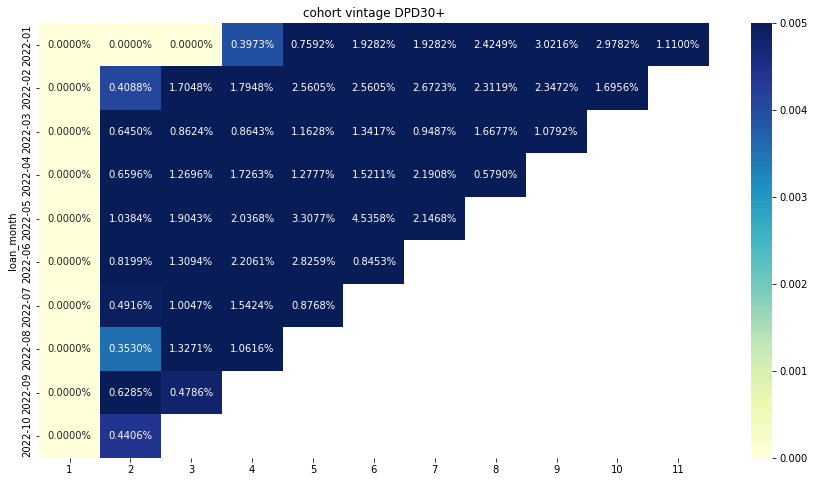

In [103]:
# cohort分析
import seaborn as sns
plt.figure(figsize=(15, 8))
plt.title('cohort vintage DPD30+')
sns.heatmap(data=df_mob_rate, annot = True, fmt = '.4%', vmin = 0.0, vmax = 0.005,cmap="YlGnBu")
plt.show()

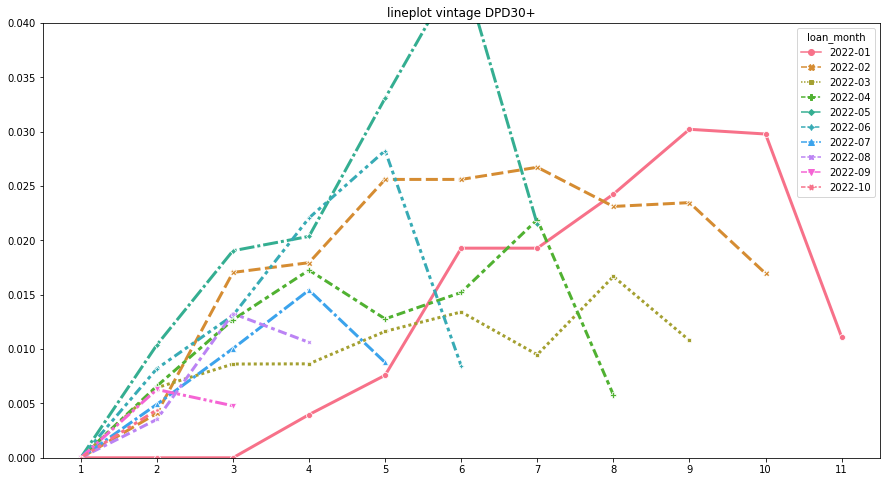

In [104]:
# vintage折线图
palette = sns.color_palette("husl", 9)
plt.figure(figsize=(15, 8))
plt.title('lineplot vintage DPD30+')
plt.ylim(0,0.04)
plt.xticks(df_mob_rate.loc[:,1:].columns.tolist())
sns.lineplot(data=df_mob_rate.loc[:,1:].T, markers=True, dashes=True, lw=3, palette=palette)
plt.show()

### **6.番外**

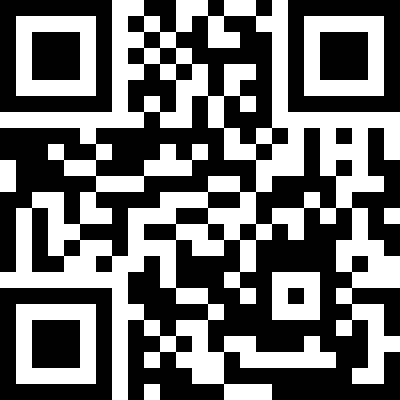